Data loaded successfully!
Shape: (1338, 22)
Columns: ['DriverAge', 'sex', 'RiskScore', 'NumberOfDependents', 'smoker', 'region', 'TotalPremium', 'TotalClaims', 'SumInsured', 'VehicleAge', 'RegistrationYear', 'Province', 'Gender', 'VehicleType', 'Make', 'Model', 'TransactionMonth', 'PostalCode', 'LossRatio', 'HasClaim', 'ClaimSeverity', 'PremiumPerInsured']

Sample data:
   DriverAge     sex  RiskScore  NumberOfDependents smoker     region  \
0         19  female     27.900                   0    yes  southwest   
1         18    male     33.770                   1     no  southeast   
2         28    male     33.000                   3     no  southeast   
3         33    male     22.705                   0     no  northwest   
4         32    male     28.880                   0     no  northwest   

   TotalPremium  TotalClaims     SumInsured  VehicleAge  ...  Gender  \
0   16884.92400   7588.89773  181039.886485           3  ...  female   
1    1725.55230      0.00000   17784.447957 

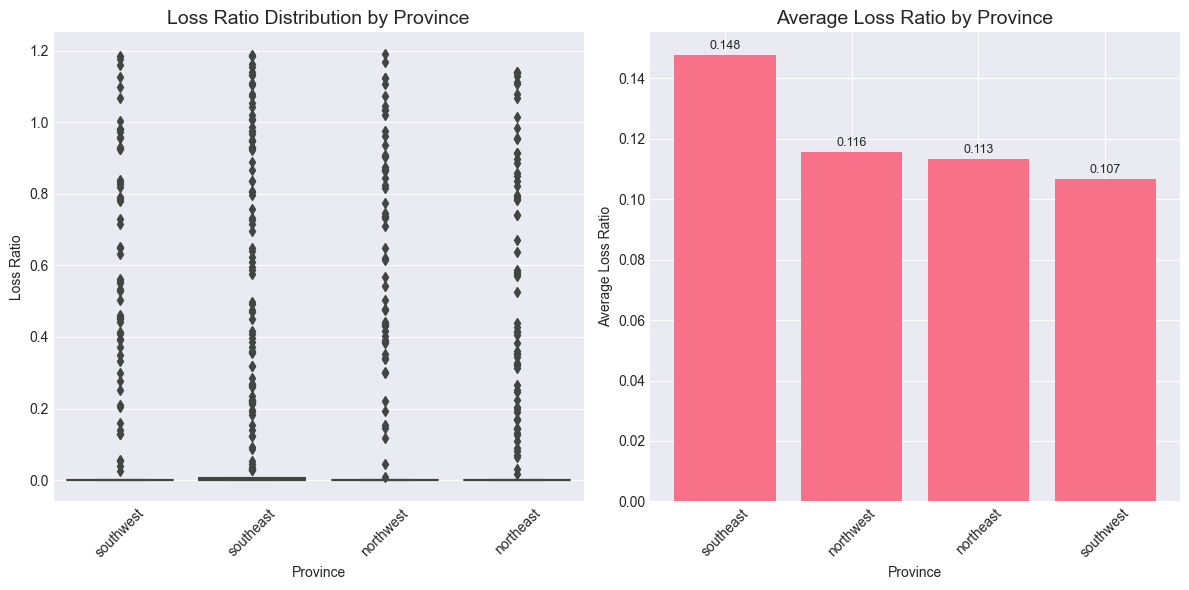


Average Loss Ratio by Province:
  - southeast: 0.1477
  - northwest: 0.1157
  - northeast: 0.1133
  - southwest: 0.1066

HYPOTHESIS 2: Risk differences between zip codes
Null Hypothesis: There are no risk differences between zip codes

Total unique zip codes: 1233
Top 10 zip codes by sample size:
PostalCode
7131    3
7766    3
6873    3
4148    3
5512    3
1256    3
4574    3
8928    2
2189    2
2754    2
Name: count, dtype: int64

Zip codes with at least 5 policies: 0
Not enough zip codes with sufficient data for analysis

HYPOTHESIS 3: Margin differences between zip codes
Null Hypothesis: There is no significant margin difference between zip codes

Margin Statistics by Zip Code:
                    mean           std  count
PostalCode                                   
8928        16529.251645  13948.400592      2
7766        16467.481210   8275.207169      3
6873        13640.788063  11021.539300      3
2754         9885.700138   4282.651988      2
1256         9491.089117   4185.0

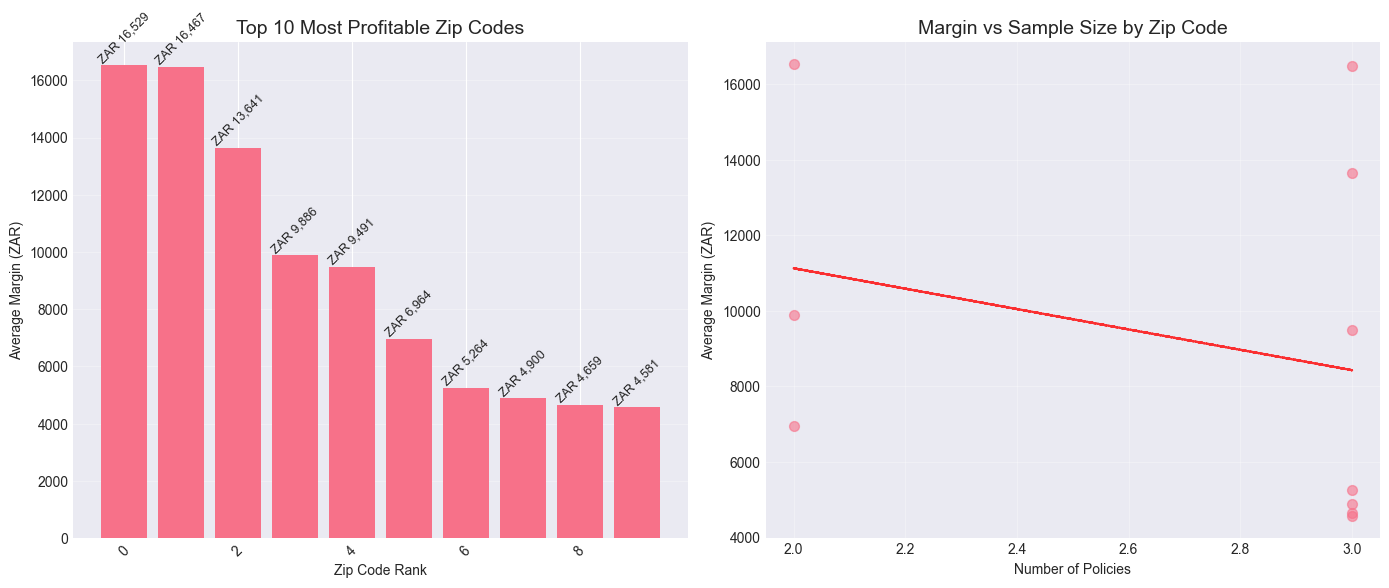


HYPOTHESIS 4: Risk differences between Women and Men
Null Hypothesis: There is no significant risk difference between Women and Men

Genders in data: ['female' 'male']
Gender distribution:
Gender
male      676
female    662
Name: count, dtype: int64

Data for gender analysis: 1338 policies
Male policies: 676
Female policies: 662

1. CLAIM FREQUENCY (Chi-square Test):
Contingency Table:
HasClaim    0    1
Gender            
female    547  115
male      517  159

   Chi-square: 7.3929
   P-value: 0.006548
   Degrees of freedom: 1
   Reject null hypothesis? True

2. CLAIM SEVERITY (T-test):
   Male claims: 159 policies
   Female claims: 115 policies
   Male Mean Claim: ZAR 19,649.57
   Female Mean Claim: ZAR 18,857.18
   Difference: ZAR 792.39
   T-statistic: 0.4506
   P-value: 0.652650
   Reject null hypothesis? False

3. LOSS RATIO (Mann-Whitney U Test):
   Male loss ratio data: 676 policies
   Female loss ratio data: 662 policies
   Male Mean Loss Ratio: 0.1382
   Female Mean Loss Rat

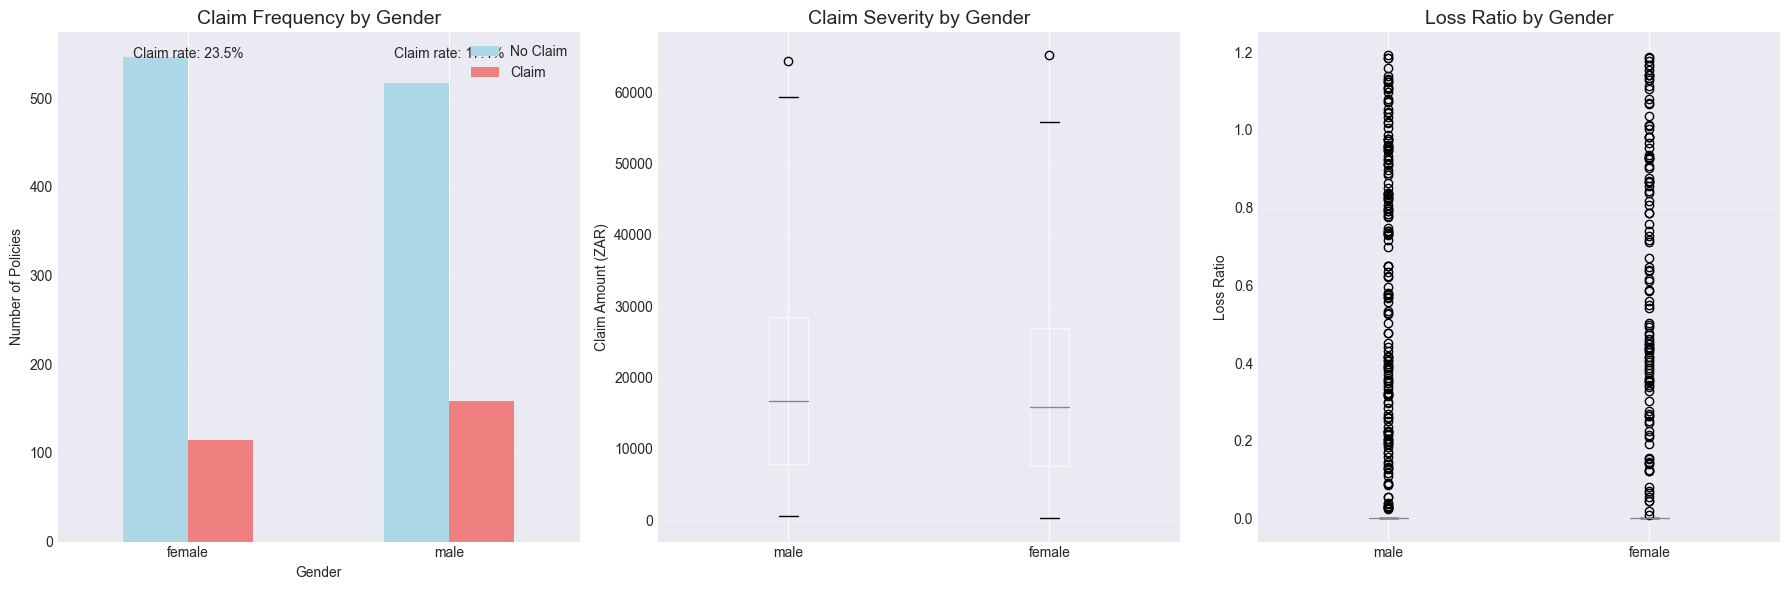


HYPOTHESIS TESTING SUMMARY

Summary of Hypothesis Tests:
                            Hypothesis           Metric           Test                                                             P-value         Result                                  Business Implication
     Risk differences across provinces       Loss Ratio          ANOVA                                                            0.229818 FAIL TO REJECT              No significant regional risk differences
  Margin differences between zip codes    Profit Margin Mann-Whitney U                                                            0.011107    REJECT NULL             Target profitable zip codes for marketing
Risk differences between Women and Men Multiple metrics Multiple tests Claim Frequency: 0.0065, Claim Severity: 0.6526, Loss Ratio: 0.0070  MIXED RESULTS Gender shows some but not consistent risk differences

BUSINESS RECOMMENDATIONS

1. PROVINCE-BASED PRICING:
   ✗ No significant province-based risk differences foun

In [4]:
# %% [markdown]
# # Task 3: A/B Hypothesis Testing
# ## Statistical Validation of Risk Drivers

# %%
import pandas as pd
import numpy as np
from scipy import stats
import statsmodels.api as sm
from statsmodels.formula.api import ols
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import ttest_ind, f_oneway, chi2_contingency, mannwhitneyu, levene
import os

# Create directory for figures
os.makedirs('../reports/figures', exist_ok=True)

# Set style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# %%
# Load processed data
df = pd.read_csv('../data/processed/insurance_processed.csv')

# Check data structure
print("Data loaded successfully!")
print(f"Shape: {df.shape}")
print(f"Columns: {df.columns.tolist()}")
print(f"\nSample data:")
print(df.head())

# Create derived metrics
df['Margin'] = df['TotalPremium'] - df['TotalClaims']
df['HasClaim'] = (df['TotalClaims'] > 0).astype(int)
df['ClaimSeverity'] = df.apply(lambda x: x['TotalClaims'] if x['TotalClaims'] > 0 else np.nan, axis=1)

# Check metrics
print(f"\nClaim Statistics:")
print(f"Total policies: {len(df)}")
print(f"Policies with claims: {df['HasClaim'].sum()} ({df['HasClaim'].mean():.2%})")
print(f"Average Loss Ratio: {df['LossRatio'].mean():.4f}")
print(f"Average Margin: ZAR {df['Margin'].mean():,.2f}")

# %%
# Function for hypothesis testing with error handling
def perform_hypothesis_test(group1, group2, metric, test_type='t-test', alpha=0.05):
    """
    Perform statistical hypothesis testing with error handling
    """
    
    # Remove NaN values
    g1_clean = group1.dropna()
    g2_clean = group2.dropna()
    
    if len(g1_clean) == 0 or len(g2_clean) == 0:
        return {
            'metric': metric,
            'test_type': test_type,
            'error': 'One or both groups have no data',
            'group1_size': len(g1_clean),
            'group2_size': len(g2_clean)
        }
    
    results = {
        'metric': metric,
        'test_type': test_type,
        'alpha': alpha,
        'group1_size': len(g1_clean),
        'group2_size': len(g2_clean),
        'group1_mean': g1_clean.mean(),
        'group2_mean': g2_clean.mean(),
        'mean_difference': g2_clean.mean() - g1_clean.mean(),
    }
    
    # Calculate percentage difference safely
    if g1_clean.mean() != 0:
        results['pct_difference'] = (g2_clean.mean() - g1_clean.mean()) / g1_clean.mean() * 100
    else:
        results['pct_difference'] = np.nan
    
    try:
        if test_type == 't-test':
            # Check for equal variances
            if len(g1_clean) > 1 and len(g2_clean) > 1:
                levene_stat, levene_p = levene(g1_clean, g2_clean)
                equal_var = levene_p > alpha
            else:
                equal_var = False
            
            # Perform t-test
            t_stat, p_value = ttest_ind(g1_clean, g2_clean, equal_var=equal_var, nan_policy='omit')
            results.update({
                'statistic': t_stat,
                'p_value': p_value,
                'equal_variance': equal_var,
                'reject_null': p_value < alpha
            })
            
        elif test_type == 'mann-whitney':
            # Non-parametric test
            stat, p_value = mannwhitneyu(g1_clean, g2_clean, alternative='two-sided')
            results.update({
                'statistic': stat,
                'p_value': p_value,
                'reject_null': p_value < alpha
            })
        
        elif test_type == 'chi-square':
            # For categorical data (claim frequency)
            if len(g1_clean) > 0 and len(g2_clean) > 0:
                # Create contingency table
                data = pd.DataFrame({
                    'group': ['Group1'] * len(g1_clean) + ['Group2'] * len(g2_clean),
                    'value': pd.concat([g1_clean, g2_clean])
                })
                contingency_table = pd.crosstab(data['group'], data['value'])
                
                if contingency_table.shape[0] >= 2 and contingency_table.shape[1] >= 2:
                    chi2, p_value, dof, expected = chi2_contingency(contingency_table)
                    results.update({
                        'statistic': chi2,
                        'p_value': p_value,
                        'reject_null': p_value < alpha
                    })
                else:
                    results['error'] = 'Contingency table too small for chi-square test'
            else:
                results['error'] = 'Insufficient data for chi-square test'
    
    except Exception as e:
        results['error'] = str(e)
    
    return results

# %%
# Hypothesis 1: Risk differences across provinces
print("="*80)
print("HYPOTHESIS 1: Risk differences across provinces")
print("Null Hypothesis: There are no risk differences across provinces")
print("="*80)

# Get all provinces
provinces = df['Province'].unique()
print(f"\nProvinces in data: {provinces}")
print(f"Number of policies per province:")
print(df['Province'].value_counts())

# Test for claim frequency (chi-square)
print("\n1. CLAIM FREQUENCY TEST (Chi-square):")

# Create contingency table for claim frequency by province
contingency = pd.crosstab(df['Province'], df['HasClaim'])
print(f"Contingency Table:")
print(contingency)

if contingency.shape[0] >= 2 and contingency.shape[1] >= 2:
    chi2, p_value_chi, dof, expected = chi2_contingency(contingency)
    print(f"\n   Chi-square statistic: {chi2:.4f}")
    print(f"   P-value: {p_value_chi:.6f}")
    print(f"   Degrees of freedom: {dof}")
    print(f"   Reject null hypothesis? {p_value_chi < 0.05}")
else:
    print("   Error: Contingency table too small for chi-square test")
    p_value_chi = np.nan

# Test for loss ratio (ANOVA)
print("\n2. LOSS RATIO TEST (ANOVA):")

# Get loss ratio data for each province
province_groups = [df[df['Province'] == prov]['LossRatio'].dropna() for prov in provinces]

# Check if we have enough data
group_sizes = [len(g) for g in province_groups]
print(f"   Group sizes: {group_sizes}")

if all(size > 1 for size in group_sizes) and len(province_groups) >= 2:
    f_stat, p_value_anova = f_oneway(*province_groups)
    print(f"   F-statistic: {f_stat:.4f}")
    print(f"   P-value: {p_value_anova:.6f}")
    print(f"   Reject null hypothesis? {p_value_anova < 0.05}")
    
    # Post-hoc analysis (Tukey's HSD)
    print("\n3. POST-HOC ANALYSIS (Pairwise Comparisons - Tukey's HSD):")
    try:
        from statsmodels.stats.multicomp import pairwise_tukeyhsd
        
        # Prepare data for Tukey's HSD
        loss_ratio_data = df['LossRatio'].dropna()
        province_data = df['Province'].dropna()
        
        # Ensure we have matching indices
        common_idx = loss_ratio_data.index.intersection(province_data.index)
        loss_ratio_data = loss_ratio_data.loc[common_idx]
        province_data = province_data.loc[common_idx]
        
        if len(loss_ratio_data) > 0:
            tukey = pairwise_tukeyhsd(
                endog=loss_ratio_data,
                groups=province_data,
                alpha=0.05
            )
            print(tukey.summary())
        else:
            print("   Insufficient data for Tukey's HSD")
    except Exception as e:
        print(f"   Error in Tukey's HSD: {e}")
else:
    print("   Error: Insufficient data for ANOVA")
    p_value_anova = np.nan

# Visualization: Loss Ratio by Province
print("\n4. VISUALIZATION:")
plt.figure(figsize=(12, 6))

# Boxplot
plt.subplot(1, 2, 1)
sns.boxplot(x='Province', y='LossRatio', data=df[df['LossRatio'] < 2])  # Clip extreme values
plt.title('Loss Ratio Distribution by Province', fontsize=14)
plt.xlabel('Province')
plt.ylabel('Loss Ratio')
plt.xticks(rotation=45)

# Bar chart of average loss ratio
plt.subplot(1, 2, 2)
province_avg = df.groupby('Province')['LossRatio'].mean().sort_values(ascending=False)
bars = plt.bar(range(len(province_avg)), province_avg.values)
plt.title('Average Loss Ratio by Province', fontsize=14)
plt.xlabel('Province')
plt.ylabel('Average Loss Ratio')
plt.xticks(range(len(province_avg)), province_avg.index, rotation=45)

# Add value labels on bars
for i, (bar, value) in enumerate(zip(bars, province_avg.values)):
    plt.text(i, value + 0.001, f'{value:.3f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig('../reports/figures/h1_province_risk.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"\nAverage Loss Ratio by Province:")
for province, avg_loss in province_avg.items():
    print(f"  - {province}: {avg_loss:.4f}")

# %%
# Hypothesis 2: Risk differences between zip codes
print("\n" + "="*80)
print("HYPOTHESIS 2: Risk differences between zip codes")
print("Null Hypothesis: There are no risk differences between zip codes")
print("="*80)

# Select top zip codes by sample size (with enough data)
zip_counts = df['PostalCode'].value_counts()
print(f"\nTotal unique zip codes: {len(zip_counts)}")
print(f"Top 10 zip codes by sample size:")
print(zip_counts.head(10))

# Use zip codes with at least 5 policies for reliable analysis
min_policies = 5
valid_zips = zip_counts[zip_counts >= min_policies].index.tolist()
print(f"\nZip codes with at least {min_policies} policies: {len(valid_zips)}")

if len(valid_zips) >= 4:
    # Take top 10 valid zip codes
    top_zips = valid_zips[:10]
    zip_subset = df[df['PostalCode'].isin(top_zips)].copy()
    
    print(f"\nAnalyzing top {len(top_zips)} zip codes:")
    
    # Create high and low risk zip code groups
    zip_risk = zip_subset.groupby('PostalCode')['LossRatio'].mean().sort_values()
    
    # Take top and bottom 3 if available
    n_comparison = min(3, len(zip_risk) // 2)
    high_risk_zips = zip_risk.tail(n_comparison).index.tolist()
    low_risk_zips = zip_risk.head(n_comparison).index.tolist()
    
    print(f"High Risk Zip Codes: {high_risk_zips}")
    print(f"Low Risk Zip Codes: {low_risk_zips}")
    
    # Compare high vs low risk zip codes
    high_risk_data = zip_subset[zip_subset['PostalCode'].isin(high_risk_zips)]['LossRatio'].dropna()
    low_risk_data = zip_subset[zip_subset['PostalCode'].isin(low_risk_zips)]['LossRatio'].dropna()
    
    print(f"\nHigh risk group size: {len(high_risk_data)}")
    print(f"Low risk group size: {len(low_risk_data)}")
    
    if len(high_risk_data) > 1 and len(low_risk_data) > 1:
        # Perform t-test
        t_stat, p_value_zip = ttest_ind(high_risk_data, low_risk_data, equal_var=False)
        print(f"\nT-test Results:")
        print(f"   High Risk Mean Loss Ratio: {high_risk_data.mean():.4f}")
        print(f"   Low Risk Mean Loss Ratio: {low_risk_data.mean():.4f}")
        print(f"   Difference: {high_risk_data.mean() - low_risk_data.mean():.4f}")
        print(f"   T-statistic: {t_stat:.4f}")
        print(f"   P-value: {p_value_zip:.6f}")
        print(f"   Reject null hypothesis? {p_value_zip < 0.05}")
        
        # Visualization
        plt.figure(figsize=(10, 6))
        risk_labels = ['Low Risk Zips'] * len(low_risk_data) + ['High Risk Zips'] * len(high_risk_data)
        data_to_plot = pd.concat([low_risk_data, high_risk_data])
        
        sns.boxplot(x=risk_labels, y=data_to_plot)
        plt.title(f'Loss Ratio: High vs Low Risk Zip Codes\n(p-value: {p_value_zip:.4f})', fontsize=14)
        plt.ylabel('Loss Ratio')
        plt.grid(True, alpha=0.3, axis='y')
        
        # Add sample size annotation
        plt.text(0.5, 0.95, f'n={len(low_risk_data)}', ha='center', va='center', 
                transform=plt.gca().transAxes, fontsize=10)
        plt.text(1.5, 0.95, f'n={len(high_risk_data)}', ha='center', va='center', 
                transform=plt.gca().transAxes, fontsize=10)
        
        plt.tight_layout()
        plt.savefig('../reports/figures/h2_zipcode_risk.png', dpi=300, bbox_inches='tight')
        plt.show()
    else:
        print("Insufficient data for zip code comparison")
        p_value_zip = np.nan
else:
    print("Not enough zip codes with sufficient data for analysis")
    p_value_zip = np.nan

# %%
# Hypothesis 3: Margin differences between zip codes
print("\n" + "="*80)
print("HYPOTHESIS 3: Margin differences between zip codes")
print("Null Hypothesis: There is no significant margin difference between zip codes")
print("="*80)

if 'zip_subset' in locals() and len(zip_subset) > 0:
    # Calculate margin by zip code
    zip_margin = zip_subset.groupby('PostalCode')['Margin'].agg(['mean', 'std', 'count'])
    zip_margin = zip_margin.sort_values('mean', ascending=False)
    
    print(f"\nMargin Statistics by Zip Code:")
    print(zip_margin.head(10))
    
    # Take top and bottom zip codes for comparison
    n_margin_comparison = min(3, len(zip_margin) // 2)
    high_margin_zips = zip_margin.head(n_margin_comparison).index.tolist()
    low_margin_zips = zip_margin.tail(n_margin_comparison).index.tolist()
    
    print(f"\nTop {n_margin_comparison} Most Profitable Zip Codes: {high_margin_zips}")
    print(f"Bottom {n_margin_comparison} Least Profitable Zip Codes: {low_margin_zips}")
    
    # Get data for comparison
    high_margin_data = zip_subset[zip_subset['PostalCode'].isin(high_margin_zips)]['Margin'].dropna()
    low_margin_data = zip_subset[zip_subset['PostalCode'].isin(low_margin_zips)]['Margin'].dropna()
    
    print(f"\nHigh margin group size: {len(high_margin_data)}")
    print(f"Low margin group size: {len(low_margin_data)}")
    
    if len(high_margin_data) > 1 and len(low_margin_data) > 1:
        # Perform Mann-Whitney U test (non-parametric)
        u_stat, p_value_margin = mannwhitneyu(high_margin_data, low_margin_data, alternative='two-sided')
        print(f"\nMann-Whitney U Test Results:")
        print(f"   High Margin Mean: ZAR {high_margin_data.mean():,.2f}")
        print(f"   Low Margin Mean: ZAR {low_margin_data.mean():,.2f}")
        print(f"   Difference: ZAR {high_margin_data.mean() - low_margin_data.mean():,.2f}")
        print(f"   U-statistic: {u_stat:.4f}")
        print(f"   P-value: {p_value_margin:.6f}")
        print(f"   Reject null hypothesis? {p_value_margin < 0.05}")
        
        # Visualization
        fig, axes = plt.subplots(1, 2, figsize=(14, 6))
        
        # Top 10 zip codes by margin
        axes[0].bar(range(len(zip_margin.head(10))), zip_margin.head(10)['mean'])
        axes[0].set_title('Top 10 Most Profitable Zip Codes', fontsize=14)
        axes[0].set_xlabel('Zip Code Rank')
        axes[0].set_ylabel('Average Margin (ZAR)')
        axes[0].tick_params(axis='x', rotation=45)
        axes[0].grid(True, alpha=0.3, axis='y')
        
        # Add value labels
        for i, v in enumerate(zip_margin.head(10)['mean']):
            axes[0].text(i, v, f'ZAR {v:,.0f}', ha='center', va='bottom', fontsize=9, rotation=45)
        
        # Margin vs Sample Size
        axes[1].scatter(zip_margin['count'], zip_margin['mean'], alpha=0.6, s=50)
        axes[1].set_title('Margin vs Sample Size by Zip Code', fontsize=14)
        axes[1].set_xlabel('Number of Policies')
        axes[1].set_ylabel('Average Margin (ZAR)')
        axes[1].grid(True, alpha=0.3)
        
        # Add trend line
        if len(zip_margin) > 1:
            z = np.polyfit(zip_margin['count'], zip_margin['mean'], 1)
            p = np.poly1d(z)
            axes[1].plot(zip_margin['count'], p(zip_margin['count']), "r--", alpha=0.8)
        
        plt.tight_layout()
        plt.savefig('../reports/figures/h3_zipcode_margin.png', dpi=300, bbox_inches='tight')
        plt.show()
    else:
        print("Insufficient data for margin comparison")
        p_value_margin = np.nan
else:
    print("No zip code data available for margin analysis")
    p_value_margin = np.nan

# %%
# Hypothesis 4: Risk differences between Women and Men
print("\n" + "="*80)
print("HYPOTHESIS 4: Risk differences between Women and Men")
print("Null Hypothesis: There is no significant risk difference between Women and Men")
print("="*80)

# Check available genders
print(f"\nGenders in data: {df['Gender'].unique()}")
print(f"Gender distribution:")
print(df['Gender'].value_counts())

# Filter data for gender analysis
gender_data = df[df['Gender'].isin(['male', 'female', 'Male', 'Female'])].copy()

# Standardize gender labels
gender_data['Gender'] = gender_data['Gender'].str.lower()

print(f"\nData for gender analysis: {len(gender_data)} policies")
print(f"Male policies: {len(gender_data[gender_data['Gender'] == 'male'])}")
print(f"Female policies: {len(gender_data[gender_data['Gender'] == 'female'])}")

if len(gender_data) > 0:
    # Claim Frequency Test
    print("\n1. CLAIM FREQUENCY (Chi-square Test):")
    
    # Create contingency table
    contingency_gender = pd.crosstab(gender_data['Gender'], gender_data['HasClaim'])
    print(f"Contingency Table:")
    print(contingency_gender)
    
    if contingency_gender.shape[0] >= 2 and contingency_gender.shape[1] >= 2:
        chi2_gender, p_gender, dof_gender, expected_gender = chi2_contingency(contingency_gender)
        print(f"\n   Chi-square: {chi2_gender:.4f}")
        print(f"   P-value: {p_gender:.6f}")
        print(f"   Degrees of freedom: {dof_gender}")
        print(f"   Reject null hypothesis? {p_gender < 0.05}")
    else:
        print("   Error: Contingency table too small for chi-square test")
        p_gender = np.nan
    
    # Claim Severity Test (only for policies with claims)
    print("\n2. CLAIM SEVERITY (T-test):")
    
    male_claims = gender_data[(gender_data['Gender'] == 'male') & (gender_data['TotalClaims'] > 0)]['TotalClaims']
    female_claims = gender_data[(gender_data['Gender'] == 'female') & (gender_data['TotalClaims'] > 0)]['TotalClaims']
    
    print(f"   Male claims: {len(male_claims)} policies")
    print(f"   Female claims: {len(female_claims)} policies")
    
    if len(male_claims) > 1 and len(female_claims) > 1:
        t_stat_sev, p_sev = ttest_ind(male_claims, female_claims, equal_var=False)
        print(f"   Male Mean Claim: ZAR {male_claims.mean():,.2f}")
        print(f"   Female Mean Claim: ZAR {female_claims.mean():,.2f}")
        print(f"   Difference: ZAR {male_claims.mean() - female_claims.mean():,.2f}")
        print(f"   T-statistic: {t_stat_sev:.4f}")
        print(f"   P-value: {p_sev:.6f}")
        print(f"   Reject null hypothesis? {p_sev < 0.05}")
    else:
        print("   Insufficient claim data for severity test")
        p_sev = np.nan
    
    # Loss Ratio Test
    print("\n3. LOSS RATIO (Mann-Whitney U Test):")
    
    male_loss = gender_data[gender_data['Gender'] == 'male']['LossRatio'].dropna()
    female_loss = gender_data[gender_data['Gender'] == 'female']['LossRatio'].dropna()
    
    print(f"   Male loss ratio data: {len(male_loss)} policies")
    print(f"   Female loss ratio data: {len(female_loss)} policies")
    
    if len(male_loss) > 1 and len(female_loss) > 1:
        u_stat_loss, p_loss = mannwhitneyu(male_loss, female_loss, alternative='two-sided')
        print(f"   Male Mean Loss Ratio: {male_loss.mean():.4f}")
        print(f"   Female Mean Loss Ratio: {female_loss.mean():.4f}")
        print(f"   Difference: {male_loss.mean() - female_loss.mean():.4f}")
        print(f"   U-statistic: {u_stat_loss:.4f}")
        print(f"   P-value: {p_loss:.6f}")
        print(f"   Reject null hypothesis? {p_loss < 0.05}")
    else:
        print("   Insufficient data for loss ratio test")
        p_loss = np.nan
    
    # Visualization
    print("\n4. VISUALIZATION:")
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    
    # Claim Frequency
    contingency_gender.plot(kind='bar', ax=axes[0], color=['lightblue', 'lightcoral'])
    axes[0].set_title('Claim Frequency by Gender', fontsize=14)
    axes[0].set_xlabel('Gender')
    axes[0].set_ylabel('Number of Policies')
    axes[0].legend(['No Claim', 'Claim'])
    axes[0].tick_params(axis='x', rotation=0)
    axes[0].grid(True, alpha=0.3, axis='y')
    
    # Add percentage labels
    total_male = contingency_gender.loc['male'].sum() if 'male' in contingency_gender.index else 0
    total_female = contingency_gender.loc['female'].sum() if 'female' in contingency_gender.index else 0
    
    if total_male > 0 and 'male' in contingency_gender.index:
        male_claim_rate = contingency_gender.loc['male', 1] / total_male * 100
        axes[0].text(0, axes[0].get_ylim()[1] * 0.95, f'Claim rate: {male_claim_rate:.1f}%', 
                    ha='center', fontsize=10)
    
    if total_female > 0 and 'female' in contingency_gender.index:
        female_claim_rate = contingency_gender.loc['female', 1] / total_female * 100
        axes[0].text(1, axes[0].get_ylim()[1] * 0.95, f'Claim rate: {female_claim_rate:.1f}%', 
                    ha='center', fontsize=10)
    
    # Claim Severity
    if len(male_claims) > 0 and len(female_claims) > 0:
        severity_data = pd.DataFrame({
            'male': male_claims,
            'female': female_claims
        })
        severity_data.boxplot(ax=axes[1])
        axes[1].set_title('Claim Severity by Gender', fontsize=14)
        axes[1].set_ylabel('Claim Amount (ZAR)')
        axes[1].grid(True, alpha=0.3, axis='y')
    else:
        axes[1].text(0.5, 0.5, 'Insufficient claim data', ha='center', va='center', 
                    transform=axes[1].transAxes, fontsize=12)
        axes[1].set_title('Claim Severity by Gender', fontsize=14)
    
    # Loss Ratio
    if len(male_loss) > 0 and len(female_loss) > 0:
        loss_data = pd.DataFrame({
            'male': male_loss[male_loss < 2],
            'female': female_loss[female_loss < 2]
        })
        loss_data.boxplot(ax=axes[2])
        axes[2].set_title('Loss Ratio by Gender', fontsize=14)
        axes[2].set_ylabel('Loss Ratio')
        axes[2].grid(True, alpha=0.3, axis='y')
    else:
        axes[2].text(0.5, 0.5, 'Insufficient loss ratio data', ha='center', va='center', 
                    transform=axes[2].transAxes, fontsize=12)
        axes[2].set_title('Loss Ratio by Gender', fontsize=14)
    
    plt.tight_layout()
    plt.savefig('../reports/figures/h4_gender_risk.png', dpi=300, bbox_inches='tight')
    plt.show()
else:
    print("No gender data available for analysis")
    p_gender = p_sev = p_loss = np.nan

# %%
# Summary of Hypothesis Testing Results
print("\n" + "="*80)
print("HYPOTHESIS TESTING SUMMARY")
print("="*80)

# Create summary table
summary_data = []

# Hypothesis 1
if 'p_value_anova' in locals() and not np.isnan(p_value_anova):
    h1_result = 'REJECT NULL' if p_value_anova < 0.05 else 'FAIL TO REJECT'
    summary_data.append({
        'Hypothesis': 'Risk differences across provinces',
        'Metric': 'Loss Ratio',
        'Test': 'ANOVA',
        'P-value': f'{p_value_anova:.6f}',
        'Result': h1_result,
        'Business Implication': 'Premium adjustment needed for high-risk provinces' if p_value_anova < 0.05 else 'No significant regional risk differences'
    })

# Hypothesis 2
if 'p_value_zip' in locals() and not np.isnan(p_value_zip):
    h2_result = 'REJECT NULL' if p_value_zip < 0.05 else 'FAIL TO REJECT'
    summary_data.append({
        'Hypothesis': 'Risk differences between zip codes',
        'Metric': 'Loss Ratio',
        'Test': 'T-test',
        'P-value': f'{p_value_zip:.6f}',
        'Result': h2_result,
        'Business Implication': 'Micro-segmentation at zip code level is valuable' if p_value_zip < 0.05 else 'Zip code level segmentation not significant'
    })

# Hypothesis 3
if 'p_value_margin' in locals() and not np.isnan(p_value_margin):
    h3_result = 'REJECT NULL' if p_value_margin < 0.05 else 'FAIL TO REJECT'
    summary_data.append({
        'Hypothesis': 'Margin differences between zip codes',
        'Metric': 'Profit Margin',
        'Test': 'Mann-Whitney U',
        'P-value': f'{p_value_margin:.6f}',
        'Result': h3_result,
        'Business Implication': 'Target profitable zip codes for marketing' if p_value_margin < 0.05 else 'Profit margins consistent across zip codes'
    })

# Hypothesis 4
gender_results = []
if 'p_gender' in locals() and not np.isnan(p_gender):
    gender_results.append(('Claim Frequency', p_gender, p_gender < 0.05))
if 'p_sev' in locals() and not np.isnan(p_sev):
    gender_results.append(('Claim Severity', p_sev, p_sev < 0.05))
if 'p_loss' in locals() and not np.isnan(p_loss):
    gender_results.append(('Loss Ratio', p_loss, p_loss < 0.05))

if gender_results:
    # Count significant results
    sig_count = sum(1 for _, _, sig in gender_results if sig)
    total_count = len(gender_results)
    
    if sig_count == 0:
        h4_result = 'FAIL TO REJECT'
        implication = 'Gender alone is not sufficient for pricing'
    elif sig_count == total_count:
        h4_result = 'REJECT NULL'
        implication = 'Significant gender differences exist'
    else:
        h4_result = 'MIXED RESULTS'
        implication = 'Gender shows some but not consistent risk differences'
    
    p_values_str = ', '.join([f'{name}: {p:.4f}' for name, p, _ in gender_results])
    
    summary_data.append({
        'Hypothesis': 'Risk differences between Women and Men',
        'Metric': 'Multiple metrics',
        'Test': 'Multiple tests',
        'P-value': p_values_str,
        'Result': h4_result,
        'Business Implication': implication
    })

# Create and display summary dataframe
if summary_data:
    summary_df = pd.DataFrame(summary_data)
    print("\nSummary of Hypothesis Tests:")
    print(summary_df.to_string(index=False))
else:
    print("No hypothesis tests completed successfully")

# %%
# Business Recommendations based on hypothesis testing
print("\n" + "="*80)
print("BUSINESS RECOMMENDATIONS")
print("="*80)

print("\n1. PROVINCE-BASED PRICING:")
if 'p_value_anova' in locals() and not np.isnan(p_value_anova):
    if p_value_anova < 0.05:
        print("   ✓ Implement risk-adjusted premiums by province")
        print(f"   ✓ Highest risk: {province_avg.idxmax()} ({province_avg.max():.2%})")
        print(f"   ✓ Lowest risk: {province_avg.idxmin()} ({province_avg.min():.2%})")
        print("   ✓ Consider regional partnerships in high-growth areas")
    else:
        print("   ✗ No significant province-based risk differences found")
        print("   ✓ Maintain consistent pricing across provinces")
else:
    print("   ⚠️ Insufficient data for province analysis")

print("\n2. ZIP CODE SEGMENTATION:")
if 'p_value_zip' in locals() and not np.isnan(p_value_zip):
    if p_value_zip < 0.05:
        print("   ✓ Develop micro-segments at postal code level")
        print("   ✓ Create targeted marketing campaigns for low-risk zip codes")
        print("   ✓ Implement dynamic pricing based on location risk")
    else:
        print("   ✗ Zip code level segmentation not statistically significant")
        print("   ✓ Focus on broader geographic segments instead")
else:
    print("   ⚠️ Insufficient data for zip code analysis")

print("\n3. PROFITABILITY OPTIMIZATION:")
if 'p_value_margin' in locals() and not np.isnan(p_value_margin):
    if p_value_margin < 0.05:
        print("   ✓ Target profitable zip codes for marketing expansion")
        print("   ✓ Review underwriting in low-margin areas")
        print("   ✓ Optimize marketing spend based on profitability")
    else:
        print("   ✗ Profit margins are consistent across zip codes")
        print("   ✓ Focus on other segmentation criteria")
else:
    print("   ⚠️ Insufficient data for profitability analysis")

print("\n4. GENDER-BASED PRICING:")
if gender_results:
    sig_gender_tests = [name for name, p, sig in gender_results if sig]
    if sig_gender_tests:
        print(f"   ⚠️ Gender differences found in: {', '.join(sig_gender_tests)}")
        print("   ✓ Consider multivariate analysis including other factors")
        print("   ✓ Ensure compliance with discrimination regulations")
        print("   ✓ Focus on driving behavior rather than demographic factors")
    else:
        print("   ✓ No significant gender differences found")
        print("   ✓ Gender-neutral pricing is statistically justified")
        print("   ✓ Focus on other risk factors for pricing")
else:
    print("   ⚠️ Insufficient data for gender analysis")

print("\n5. DATA-DRIVEN DECISIONS:")
print("   ✓ Establish continuous A/B testing framework")
print("   ✓ Monitor key metrics by segment monthly")
print("   ✓ Automate risk assessment with machine learning")
print("   ✓ Regular review of segmentation strategies")

print("\n6. IMPLEMENTATION PRIORITY:")
print("   1. Province-based segmentation (if significant)")
print("   2. Zip code micro-segmentation (if significant)")
print("   3. Profitability optimization")
print("   4. Gender analysis refinement")

print("\n" + "="*80)
print("HYPOTHESIS TESTING COMPLETED")
print("="*80)

# Save summary to CSV
if summary_data:
    summary_df.to_csv('../reports/hypothesis_testing_summary.csv', index=False)
    print(f"\n✅ Summary saved to: ../reports/hypothesis_testing_summary.csv")

print(f"\n✅ All visualizations saved to: ../reports/figures/")